In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
import pickle
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
df = pd.read_csv('data/cfpb_complaints_target_creation.csv')

print(f"Dataset loaded: {len(df):,} complaints")
print(f"Target variable: resolution_tier")
print(f"\nTarget distribution:")
print(df['resolution_tier'].value_counts().sort_index())

Dataset loaded: 1,399,218 complaints
Target variable: resolution_tier

Target distribution:
resolution_tier
0    844951
1    528887
2     25380
Name: count, dtype: int64


In [3]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,Yes,NaN,i am writing to have the following information...,writing have the following information removed...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate,1,2025-01
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,Yes,NaN,i am a victim of identity theft. please delete...,victim identity theft. please delete remove th...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal,1,2024-07
2,2025-09-14,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"SANTANDER HOLDINGS USA, INC.",PA,19143,Web,Closed with explanation,Yes,NaN,"my name is xxxx xxxx, and i am formally disput...","name , and formally disputing fraudulent auto ...",-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140,27,T27_credit-reporting_federal,Credit Reporting Errors,Moderate,0,2025-09
3,2025-05-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,Web,Closed with non-monetary relief,Yes,NaN,"upon reviewing my credit report, i have identi...","upon reviewing credit report, have identified ...",0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal,1,2025-05
4,2025-12-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Kubota North America Corporation,MS,391XX,Web,Closed with explanation,Yes,NaN,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17,3,T03_account_bank,Account / Payment Issues,Minimal,0,2025-12


In [4]:
print("\n" + "="*80)
print("FEATURE DEFINITION")
print("="*80)

# Features to use for modeling
feature_cols = [
    # Sentiment features
    'sentiment_compound', 'sentiment_neg', 'sentiment_pos', 'sentiment_neu',
    
    # Linguistic markers
    'urgency_score', 'churn_intent', 'loyalty_score',
    
    # Text statistics
    'text_length', 'word_count'
]

print(f"\nFeatures selected: {len(feature_cols)}")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i}. {feat}")


FEATURE DEFINITION

Features selected: 9
  1. sentiment_compound
  2. sentiment_neg
  3. sentiment_pos
  4. sentiment_neu
  5. urgency_score
  6. churn_intent
  7. loyalty_score
  8. text_length
  9. word_count


In [5]:
df['Date received'] = pd.to_datetime(df['Date received'])

In [6]:
print("\n" + "="*80)
print("CREATING OOS/OOT SPLITS")
print("="*80)

df['split'] = 'excluded'

# Training period: Feb 2024 - Jul 2025
train_mask = (df['Date received'] >= '2024-02-01') & (df['Date received'] < '2025-08-01')

# OOT (Out-of-Time): Aug 2025 - Nov 2025
oot_mask = (df['Date received'] >= '2025-08-01') & (df['Date received'] < '2025-12-01')

df.loc[train_mask, 'split'] = 'train'
df.loc[oot_mask, 'split'] = 'oot'

print("\nSplit distribution:")
print(df['split'].value_counts())

train_data = df[df['split'] == 'train'].copy()
oot_data = df[df['split'] == 'oot'].copy()

print(f"\nTraining period: {train_data['Date received'].min().date()} to {train_data['Date received'].max().date()}")
print(f"OOT period: {oot_data['Date received'].min().date()} to {oot_data['Date received'].max().date()}")
print(f"Excluded period: Dec 2025 - Feb 2026 ({(df['split']=='excluded').sum():,} complaints)")


CREATING OOS/OOT SPLITS

Split distribution:
split
train       787500
excluded    433992
oot         177726
Name: count, dtype: int64

Training period: 2024-02-01 to 2025-07-31
OOT period: 2025-08-01 to 2025-11-30
Excluded period: Dec 2025 - Feb 2026 (433,992 complaints)


In [7]:
# OOS (Out-of-Sample) split from training data
# 20% random stratified sample

X_train_full = train_data[feature_cols].copy()
y_train_full = train_data['resolution_tier'].copy()

X_train, X_oos, y_train, y_oos = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# OOT set
X_oot = oot_data[feature_cols].copy()
y_oot = oot_data['resolution_tier'].copy()

print("\n" + "-"*80)
print("FINAL SPLIT SIZES")
print("-"*80)
print(f"\nTrain set: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Target distribution:")
for tier in sorted(y_train.unique()):
    count = (y_train == tier).sum()
    pct = count / len(y_train) * 100
    print(f"    Tier {tier}: {count:,} ({pct:.1f}%)")

print(f"\nOOS set: {len(X_oos):,} ({len(X_oos)/len(df)*100:.1f}%)")
print(f"  Target distribution:")
for tier in sorted(y_oos.unique()):
    count = (y_oos == tier).sum()
    pct = count / len(y_oos) * 100
    print(f"    Tier {tier}: {count:,} ({pct:.1f}%)")

print(f"\nOOT set: {len(X_oot):,} ({len(X_oot)/len(df)*100:.1f}%)")
print(f"  Target distribution:")
for tier in sorted(y_oot.unique()):
    count = (y_oot == tier).sum()
    pct = count / len(y_oot) * 100
    print(f"    Tier {tier}: {count:,} ({pct:.1f}%)")


--------------------------------------------------------------------------------
FINAL SPLIT SIZES
--------------------------------------------------------------------------------

Train set: 630,000 (45.0%)
  Target distribution:
    Tier 0: 361,770 (57.4%)
    Tier 1: 259,444 (41.2%)
    Tier 2: 8,786 (1.4%)

OOS set: 157,500 (11.3%)
  Target distribution:
    Tier 0: 90,442 (57.4%)
    Tier 1: 64,861 (41.2%)
    Tier 2: 2,197 (1.4%)

OOT set: 177,726 (12.7%)
  Target distribution:
    Tier 0: 119,787 (67.4%)
    Tier 1: 55,199 (31.1%)
    Tier 2: 2,740 (1.5%)


In [11]:
missing_train = X_train.isnull().sum()
if missing_train.sum() > 0:
    print("\nMissing values in training set:")
    print(missing_train[missing_train > 0])
    
    # Fill missing values with 0 (or median for continuous features)
    X_train = X_train.fillna(0)
    X_oos = X_oos.fillna(0)
    X_oot = X_oot.fillna(0)
    
    print("\nMissing values filled with 0")
else:
    print("\nNo missing values in dataset")


No missing values in dataset


In [15]:
df.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,split
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,Yes,NaN,i am writing to have the following information...,writing have the following information removed...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate,1,2025-01,train
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,Yes,NaN,i am a victim of identity theft. please delete...,victim identity theft. please delete remove th...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal,1,2024-07,train


In [10]:
print("\n" + "="*80)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*80)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    )
)

print("\nTraining Logistic Regression...")
lr.fit(X_train, y_train)
print("Training complete")


MODEL 1: LOGISTIC REGRESSION

Training Logistic Regression...
Training complete


In [11]:
# OOS predictions
y_pred_oos_lr = lr.predict(X_oos)
y_proba_oos_lr = lr.predict_proba(X_oos)

# Evaluation
print("\n" + "-"*80)
print("OOS PERFORMANCE")
print("-"*80)
print("\nClassification Report:")
print(classification_report(y_oos, y_pred_oos_lr, 
                          target_names=['Tier 0', 'Tier 1', 'Tier 2'],
                          digits=4))

# Multi-class AUC
y_oos_bin = label_binarize(y_oos, classes=[0, 1, 2])
auc_ovo_lr = roc_auc_score(y_oos_bin, y_proba_oos_lr, 
                            multi_class='ovo', average='macro')
print(f"Multi-class AUC (one-vs-one): {auc_ovo_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_oos, y_pred_oos_lr)
print("\nConfusion Matrix:")
print(cm_lr)


--------------------------------------------------------------------------------
OOS PERFORMANCE
--------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      Tier 0     0.6592    0.1956    0.3017     90442
      Tier 1     0.4605    0.6548    0.5407     64861
      Tier 2     0.0387    0.6777    0.0733      2197

    accuracy                         0.3914    157500
   macro avg     0.3861    0.5094    0.3052    157500
weighted avg     0.5687    0.3914    0.3969    157500

Multi-class AUC (one-vs-one): 0.6225

Confusion Matrix:
[[17691 49319 23432]
 [ 8883 42472 13506]
 [  263   445  1489]]


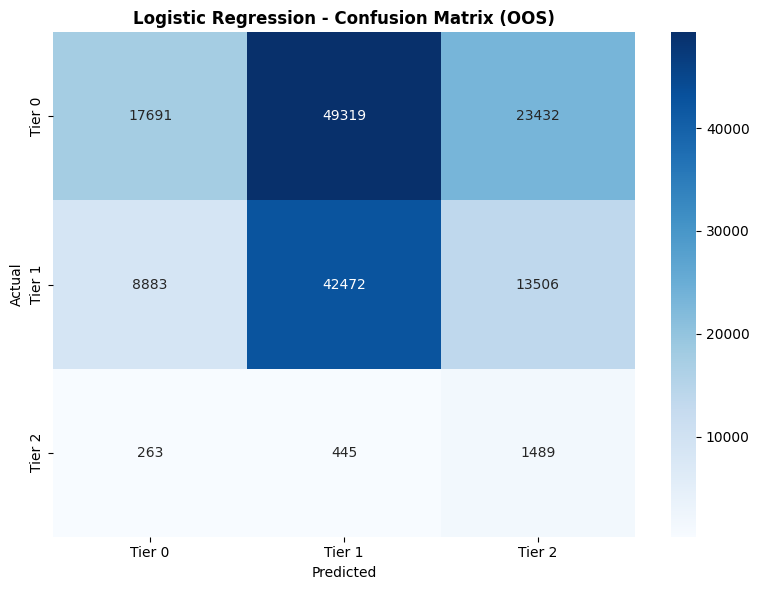

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Tier 0', 'Tier 1', 'Tier 2'],
            yticklabels=['Tier 0', 'Tier 1', 'Tier 2'])
ax.set_title('Logistic Regression - Confusion Matrix (OOS)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
# plt.savefig('outputs/lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print("\n" + "="*80)
print("MODEL 1b: LOGISTIC REGRESSION WITH CUSTOM WEIGHTS")
print("="*80)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight={0:1, 1:2, 2:10} ,
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    )
)

print("\nTraining Logistic Regression...")
lr.fit(X_train, y_train)
print("Training complete")


MODEL 1b: LOGISTIC REGRESSION WITH CUSTOM WEIGHTS

Training Logistic Regression...
Training complete


In [14]:
# OOS predictions
y_pred_oos_lr = lr.predict(X_oos)
y_proba_oos_lr = lr.predict_proba(X_oos)

# Evaluation
print("\n" + "-"*80)
print("OOS PERFORMANCE")
print("-"*80)
print("\nClassification Report:")
print(classification_report(y_oos, y_pred_oos_lr, 
                          target_names=['Tier 0', 'Tier 1', 'Tier 2'],
                          digits=4))

# Multi-class AUC
y_oos_bin = label_binarize(y_oos, classes=[0, 1, 2])
auc_ovo_lr = roc_auc_score(y_oos_bin, y_proba_oos_lr, 
                            multi_class='ovo', average='macro')
print(f"Multi-class AUC (one-vs-one): {auc_ovo_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_oos, y_pred_oos_lr)
print("\nConfusion Matrix:")
print(cm_lr)


--------------------------------------------------------------------------------
OOS PERFORMANCE
--------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      Tier 0     0.7297    0.1575    0.2591     90442
      Tier 1     0.4429    0.9191    0.5978     64861
      Tier 2     0.0897    0.1379    0.1087      2197

    accuracy                         0.4709    157500
   macro avg     0.4208    0.4049    0.3219    157500
weighted avg     0.6027    0.4709    0.3965    157500

Multi-class AUC (one-vs-one): 0.6343

Confusion Matrix:
[[14249 73695  2498]
 [ 4671 59613   577]
 [  608  1286   303]]


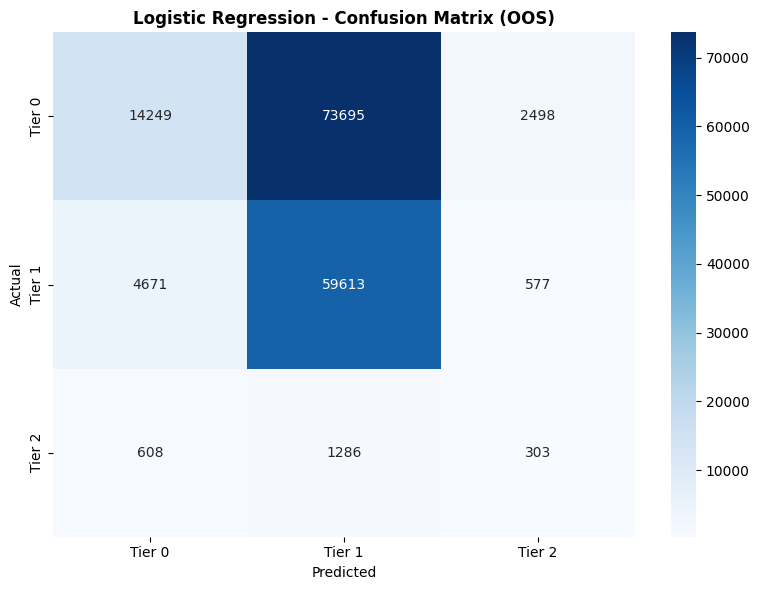

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Tier 0', 'Tier 1', 'Tier 2'],
            yticklabels=['Tier 0', 'Tier 1', 'Tier 2'])
ax.set_title('Logistic Regression - Confusion Matrix (OOS)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
# plt.savefig('outputs/lr_confusion_matrix_custom.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST")
print("="*80)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("\nTraining Random Forest...")
rf.fit(X_train, y_train)
print("Training complete")


MODEL 2: RANDOM FOREST

Training Random Forest...
Training complete


In [17]:
# OOS predictions
y_pred_oos_rf = rf.predict(X_oos)
y_proba_oos_rf = rf.predict_proba(X_oos)

# Evaluation
print("\n" + "-"*80)
print("OOS PERFORMANCE")
print("-"*80)
print("\nClassification Report:")
print(classification_report(y_oos, y_pred_oos_rf,
                          target_names=['Tier 0', 'Tier 1', 'Tier 2'],
                          digits=4))


--------------------------------------------------------------------------------
OOS PERFORMANCE
--------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      Tier 0     0.7040    0.4440    0.5445     90442
      Tier 1     0.5340    0.6927    0.6030     64861
      Tier 2     0.0646    0.4802    0.1139      2197

    accuracy                         0.5469    157500
   macro avg     0.4342    0.5389    0.4205    157500
weighted avg     0.6251    0.5469    0.5626    157500



In [18]:
# Multi-class AUC
auc_ovo_rf = roc_auc_score(y_oos_bin, y_proba_oos_rf,
                           multi_class='ovo', average='macro')
print(f"Multi-class AUC (one-vs-one): {auc_ovo_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_oos, y_pred_oos_rf)
print("\nConfusion Matrix:")
print(cm_rf)

Multi-class AUC (one-vs-one): 0.7116

Confusion Matrix:
[[40155 39011 11276]
 [15942 44926  3993]
 [  942   200  1055]]


In [19]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "-"*80)
print("FEATURE IMPORTANCE")
print("-"*80)
print(feature_importance.to_string(index=False))


--------------------------------------------------------------------------------
FEATURE IMPORTANCE
--------------------------------------------------------------------------------
           feature  importance
     sentiment_neu    0.149682
     loyalty_score    0.140213
       text_length    0.130013
        word_count    0.126458
sentiment_compound    0.118276
     sentiment_pos    0.116565
     sentiment_neg    0.100754
      churn_intent    0.079782
     urgency_score    0.038257


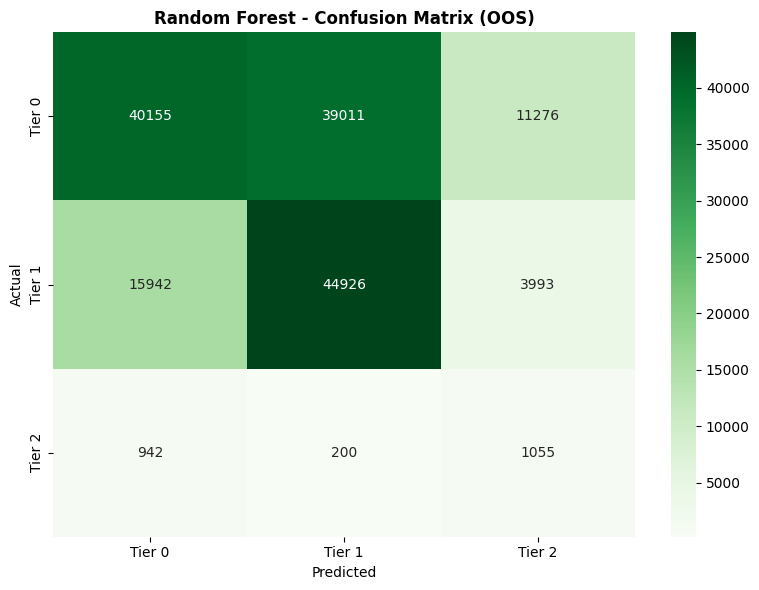

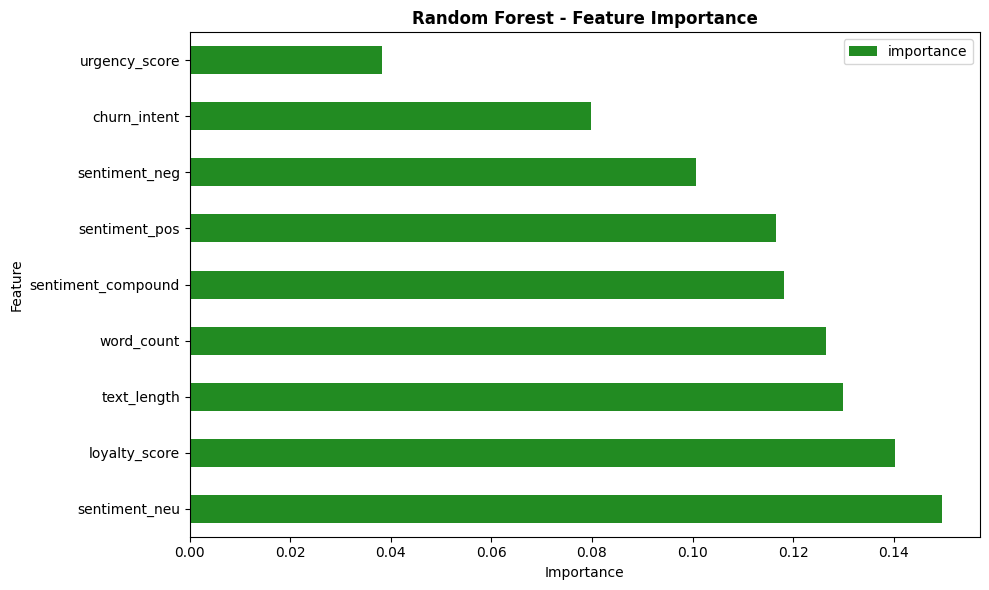

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Tier 0', 'Tier 1', 'Tier 2'],
            yticklabels=['Tier 0', 'Tier 1', 'Tier 2'])
ax.set_title('Random Forest - Confusion Matrix (OOS)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
# plt.savefig('outputs/rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='feature', y='importance', kind='barh', ax=ax, color='forestgreen')
ax.set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
# plt.savefig('outputs/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
print("\n" + "="*80)
print("MODEL 3: XGBOOST")
print("="*80)

# Calculate class weights
class_counts = y_train.value_counts()
total = len(y_train)
weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)

sample_weights = y_train.map(weights)

print("\nTraining XGBoost...")
xgb.fit(X_train, y_train, sample_weight=sample_weights)
print("Training complete")


MODEL 3: XGBOOST

Training XGBoost...
Training complete


In [22]:
# OOS predictions
y_pred_oos_xgb = xgb.predict(X_oos)
y_proba_oos_xgb = xgb.predict_proba(X_oos)

# Evaluation
print("\n" + "-"*80)
print("OOS PERFORMANCE")
print("-"*80)
print("\nClassification Report:")
print(classification_report(y_oos, y_pred_oos_xgb,
                          target_names=['Tier 0', 'Tier 1', 'Tier 2'],
                          digits=4))

# Multi-class AUC
auc_ovo_xgb = roc_auc_score(y_oos_bin, y_proba_oos_xgb,
                            multi_class='ovo', average='macro')
print(f"Multi-class AUC (one-vs-one): {auc_ovo_xgb:.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_oos, y_pred_oos_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)


--------------------------------------------------------------------------------
OOS PERFORMANCE
--------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      Tier 0     0.7012    0.4207    0.5258     90442
      Tier 1     0.5306    0.6969    0.6025     64861
      Tier 2     0.0638    0.5244    0.1138      2197

    accuracy                         0.5359    157500
   macro avg     0.4319    0.5473    0.4140    157500
weighted avg     0.6220    0.5359    0.5517    157500

Multi-class AUC (one-vs-one): 0.7132

Confusion Matrix:
[[38046 39766 12630]
 [15389 45203  4269]
 [  827   218  1152]]


In [23]:
# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "-"*80)
print("FEATURE IMPORTANCE")
print("-"*80)
print(feature_importance_xgb.to_string(index=False))


--------------------------------------------------------------------------------
FEATURE IMPORTANCE
--------------------------------------------------------------------------------
           feature  importance
     loyalty_score    0.285446
      churn_intent    0.190915
     sentiment_neu    0.094956
     urgency_score    0.077586
        word_count    0.077553
     sentiment_pos    0.075417
       text_length    0.068159
     sentiment_neg    0.065163
sentiment_compound    0.064807


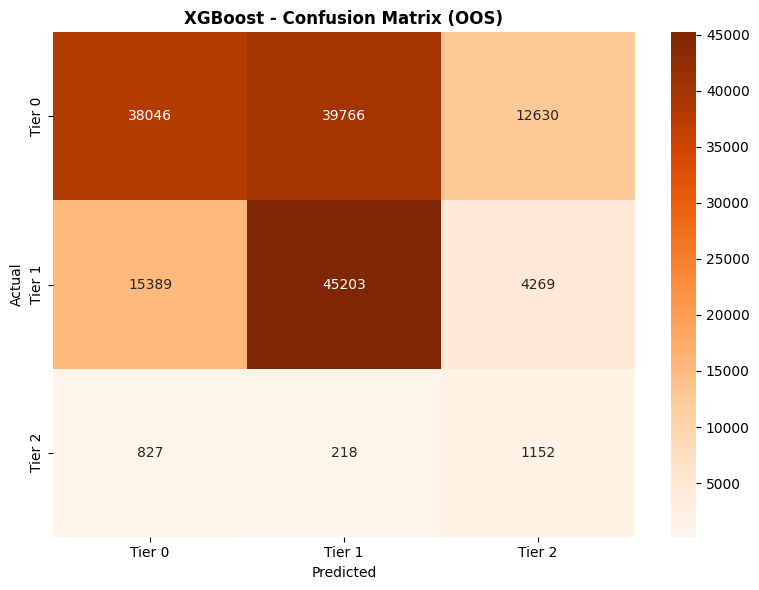

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Tier 0', 'Tier 1', 'Tier 2'],
            yticklabels=['Tier 0', 'Tier 1', 'Tier 2'])
ax.set_title('XGBoost - Confusion Matrix (OOS)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
# plt.savefig('outputs/xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

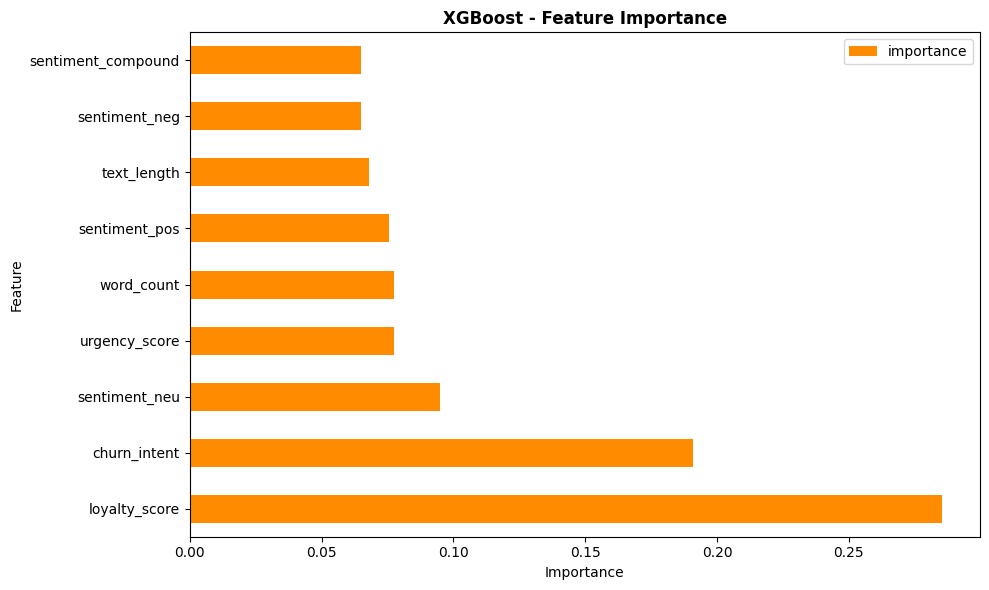

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance_xgb.plot(x='feature', y='importance', kind='barh', ax=ax, color='darkorange')
ax.set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
# plt.savefig('outputs/xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'OOS_AUC': [auc_ovo_lr, auc_ovo_rf, auc_ovo_xgb],
    'OOS_Accuracy': [
        (y_pred_oos_lr == y_oos).mean(),
        (y_pred_oos_rf == y_oos).mean(),
        (y_pred_oos_xgb == y_oos).mean()
    ]
})

comparison = comparison.sort_values('OOS_AUC', ascending=False)

print("\n")
print(comparison.to_string(index=False))

best_model_name = comparison.iloc[0]['Model']
best_auc = comparison.iloc[0]['OOS_AUC']

print(f"\n{'='*80}")
print(f"Best Model: {best_model_name}")
print(f"OOS AUC: {best_auc:.4f}")
print(f"{'='*80}")

# Select best model
if best_model_name == 'Random Forest':
    best_model = rf
    y_pred_best = y_pred_oos_rf
    y_proba_best = y_proba_oos_rf
elif best_model_name == 'XGBoost':
    best_model = xgb
    y_pred_best = y_pred_oos_xgb
    y_proba_best = y_proba_oos_xgb
else:
    best_model = lr
    y_pred_best = y_pred_oos_lr
    y_proba_best = y_proba_oos_lr


MODEL COMPARISON


              Model  OOS_AUC  OOS_Accuracy
            XGBoost 0.713178      0.535879
      Random Forest 0.711619      0.546895
Logistic Regression 0.634338      0.470889

Best Model: XGBoost
OOS AUC: 0.7132


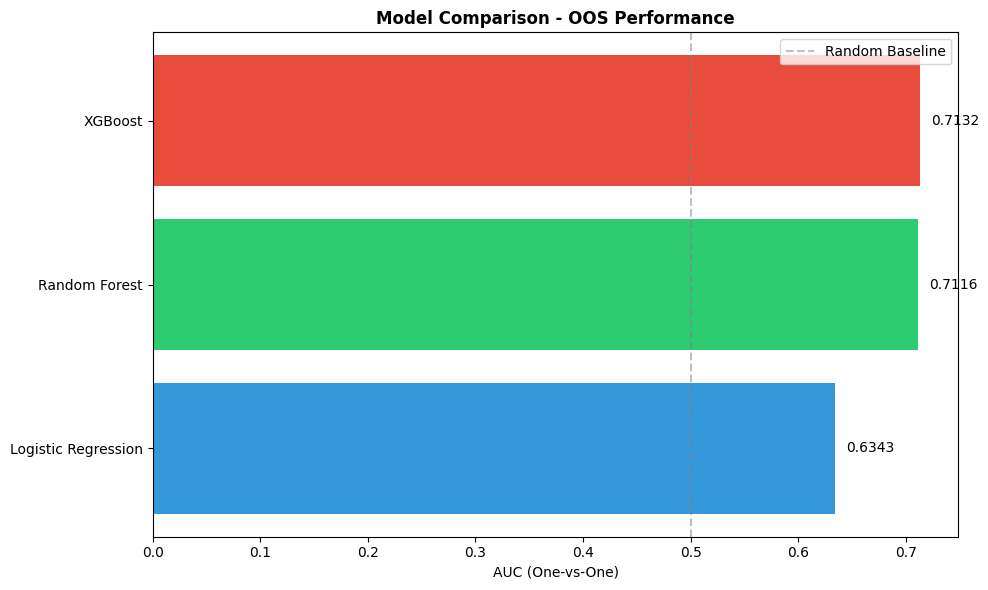

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison_sorted = comparison.sort_values('OOS_AUC')
ax.barh(comparison_sorted['Model'], comparison_sorted['OOS_AUC'], color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_xlabel('AUC (One-vs-One)')
ax.set_title('Model Comparison - OOS Performance', fontsize=12, fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random Baseline')
for i, (model, auc) in enumerate(zip(comparison_sorted['Model'], comparison_sorted['OOS_AUC'])):
    ax.text(auc + 0.01, i, f'{auc:.4f}', va='center')
ax.legend()
plt.tight_layout()
# plt.savefig('outputs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
print("\n" + "="*80)
print("TEMPORAL VALIDATION - OOT TEST")
print("="*80)

print(f"\nTesting ({best_model_name}) on OOT set...")
print(f"OOT period: {oot_data['Date received'].min().date()} to {oot_data['Date received'].max().date()}")

y_pred_oot = best_model.predict(X_oot)
y_proba_oot = best_model.predict_proba(X_oot)

print("\n" + "-"*80)
print("OOT PERFORMANCE")
print("-"*80)
print("\nClassification Report:")
print(classification_report(y_oot, y_pred_oot,
                          target_names=['Tier 0', 'Tier 1', 'Tier 2'],
                          digits=4))

# Multi-class AUC
y_oot_bin = label_binarize(y_oot, classes=[0, 1, 2])
auc_ovo_oot = roc_auc_score(y_oot_bin, y_proba_oot,
                            multi_class='ovo', average='macro')
print(f"Multi-class AUC (one-vs-one): {auc_ovo_oot:.4f}")

# Generalization gap
generalization_gap = best_auc - auc_ovo_oot
print(f"\nGeneralization gap: {generalization_gap:.4f} ({generalization_gap/best_auc*100:.1f}%)")

if auc_ovo_oot > 0.65:
    print("Excellent generalization")
elif auc_ovo_oot > 0.60:
    print("Good generalization")
elif auc_ovo_oot > 0.55:
    print("Moderate generalization")
else:
    print("Poor generalization")

# Confusion Matrix
cm_oot = confusion_matrix(y_oot, y_pred_oot)
print("\nConfusion Matrix:")
print(cm_oot)


TEMPORAL VALIDATION - OOT TEST

Testing (XGBoost) on OOT set...
OOT period: 2025-08-01 to 2025-11-30

--------------------------------------------------------------------------------
OOT PERFORMANCE
--------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      Tier 0     0.6982    0.3939    0.5036    119787
      Tier 1     0.3627    0.5665    0.4423     55199
      Tier 2     0.0592    0.5179    0.1063      2740

    accuracy                         0.4494    177726
   macro avg     0.3734    0.4927    0.3507    177726
weighted avg     0.5842    0.4494    0.4784    177726

Multi-class AUC (one-vs-one): 0.6408

Generalization gap: 0.0723 (10.1%)
Good generalization

Confusion Matrix:
[[47180 54680 17927]
 [19325 31269  4605]
 [ 1069   252  1419]]


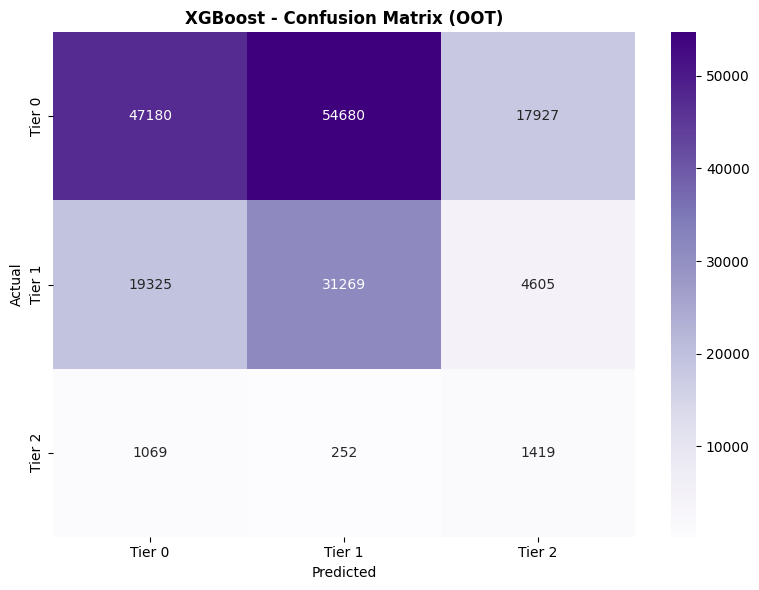

In [29]:
# Visualize OOT confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_oot, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Tier 0', 'Tier 1', 'Tier 2'],
            yticklabels=['Tier 0', 'Tier 1', 'Tier 2'])
ax.set_title(f'{best_model_name} - Confusion Matrix (OOT)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
# plt.savefig('outputs/oot_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
print("\n" + "="*80)
print("PER-TIER ANALYSIS")
print("="*80)

for tier in [0, 1, 2]:
    tier_name = ['Tier 0 (Explanation)', 'Tier 1 (Service Recovery)', 
                 'Tier 2 (Compensation)'][tier]
    
    print(f"\n{'-'*80}")
    print(f"{tier_name}")
    print(f"{'-'*80}")
    
    # Binary classification: Tier X vs rest
    y_binary_oos = (y_oos == tier).astype(int)
    y_proba_binary_oos = y_proba_best[:, tier]
    
    y_binary_oot = (y_oot == tier).astype(int)
    y_proba_binary_oot = y_proba_oot[:, tier]
    
    # OOS metrics
    auc_oos = roc_auc_score(y_binary_oos, y_proba_binary_oos)
    
    # OOT metrics
    auc_oot = roc_auc_score(y_binary_oot, y_proba_binary_oot)
    
    print(f"OOS AUC (one-vs-rest): {auc_oos:.4f}")
    print(f"OOT AUC (one-vs-rest): {auc_oot:.4f}")
    print(f"Generalization gap: {auc_oos - auc_oot:.4f}")


PER-TIER ANALYSIS

--------------------------------------------------------------------------------
Tier 0 (Explanation)
--------------------------------------------------------------------------------
OOS AUC (one-vs-rest): 0.6087
OOT AUC (one-vs-rest): 0.5113
Generalization gap: 0.0974

--------------------------------------------------------------------------------
Tier 1 (Service Recovery)
--------------------------------------------------------------------------------
OOS AUC (one-vs-rest): 0.6846
OOT AUC (one-vs-rest): 0.5876
Generalization gap: 0.0970

--------------------------------------------------------------------------------
Tier 2 (Compensation)
--------------------------------------------------------------------------------
OOS AUC (one-vs-rest): 0.8462
OOT AUC (one-vs-rest): 0.8236
Generalization gap: 0.0226


In [31]:
df.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,split
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,Yes,NaN,i am writing to have the following information...,writing have the following information removed...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate,1,2025-01,train
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,Yes,NaN,i am a victim of identity theft. please delete...,victim identity theft. please delete remove th...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal,1,2024-07,train
